# 1. Library Import

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. LOAD DATASET

In [23]:
file_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
train_df = pd.read_csv(file_path)

print("Dataset Telco Churn Berhasil Dimuat!")
print(f"Dimensi Data: {train_df.shape[0]} Baris, {train_df.shape[1]} Kolom")
print(f"\nDistribusi Target:\n{train_df['Churn'].value_counts()}")

Dataset Telco Churn Berhasil Dimuat!
Dimensi Data: 7043 Baris, 21 Kolom

Distribusi Target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# 3. Feature dan Label

In [24]:
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Encode target ke 0/1 
train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})

X = train_df.drop(columns=['customerID', 'Churn'])
y = train_df['Churn']

print(f"✅ Pemisahan Fitur dan Target Selesai.")
print(f"Jumlah Fitur: {X.shape[1]} kolom | Target: {y.name}")

✅ Pemisahan Fitur dan Target Selesai.
Jumlah Fitur: 19 kolom | Target: Churn


# 4. Split Dataset

In [25]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Split Data Selesai:")
print(f"   - Jumlah Data Training : {X_train_raw.shape[0]} baris")
print(f"   - Jumlah Data Testing  : {X_test_raw.shape[0]} baris")

✅ Split Data Selesai:
   - Jumlah Data Training : 5634 baris
   - Jumlah Data Testing  : 1409 baris


# 5. Preprocessing

In [26]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed  = preprocessor.transform(X_test_raw)

# Mengambil nama fitur setelah encoding
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
nama_fitur_final = numerical_cols + list(cat_features)

print(f"✅ Preprocessing Selesai!")
print(f"Dimensi data training setelah encode: {X_train_processed.shape}")

✅ Preprocessing Selesai!
Dimensi data training setelah encode: (5634, 46)


# 6. Handling Imbalance (SMOTE)

In [27]:
# Versi A: Data Asli (Imbalance)
X_train_asli = X_train_processed
y_train_asli = y_train

# Versi B: SMOTE (Balanced)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f" Dua Versi Data Siap Diuji:")
print(f"   - Data Asli (Imbalance) : {X_train_asli.shape[0]} baris")
print(f"   - Data SMOTE (Balanced) : {X_train_smote.shape[0]} baris")
print(f"\nDistribusi SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

 Dua Versi Data Siap Diuji:
   - Data Asli (Imbalance) : 5634 baris
   - Data SMOTE (Balanced) : 8278 baris

Distribusi SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


# 7. Training dan Hyperparameter (HPO)

In [28]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Menjalankan HPO pada Data Asli (Imbalance) ---")
grid_asli = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid, 
    cv=cv, scoring='roc_auc', 
    n_jobs=-1, verbose=1
)
grid_asli.fit(X_train_asli, y_train_asli)
best_params_asli = grid_asli.best_params_

print("\n--- Menjalankan HPO pada Data SMOTE (Balanced) ---")
grid_smote = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_smote.fit(X_train_smote, y_train_smote)
best_params_smote = grid_smote.best_params_

print(f"\n[HPO Selesai]")
print(f"Best Params Asli  : {best_params_asli}")
print(f"Best Params SMOTE : {best_params_smote}")

--- Menjalankan HPO pada Data Asli (Imbalance) ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Menjalankan HPO pada Data SMOTE (Balanced) ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits

[HPO Selesai]
Best Params Asli  : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Params SMOTE : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}


# 8. Akurasi dan Threshold

In [29]:
# Buat model final dari best params
dt_asli_final = DecisionTreeClassifier(random_state=42, **best_params_asli).fit(X_train_asli, y_train_asli)
dt_smote_final = DecisionTreeClassifier(random_state=42, **best_params_smote).fit(X_train_smote, y_train_smote)

# Prediksi
y_pred_asli  = dt_asli_final.predict(X_test_processed)
y_pred_smote = dt_smote_final.predict(X_test_processed)

y_proba_asli  = dt_asli_final.predict_proba(X_test_processed)[:, 1]
y_proba_smote = dt_smote_final.predict_proba(X_test_processed)[:, 1]

# Metrics
acc_asli  = accuracy_score(y_test, y_pred_asli)
acc_smote = accuracy_score(y_test, y_pred_smote)
roc_asli  = roc_auc_score(y_test, y_proba_asli)
roc_smote = roc_auc_score(y_test, y_proba_smote)
f1_asli   = f1_score(y_test, y_pred_asli)
f1_smote  = f1_score(y_test, y_pred_smote)

print(f"Akurasi Model Data Asli  : {acc_asli*100:.2f}%")
print(f"Akurasi Model Data SMOTE : {acc_smote*100:.2f}%")
print(f"ROC-AUC Data Asli        : {roc_asli:.4f}")
print(f"ROC-AUC Data SMOTE       : {roc_smote:.4f}")
print(f"F1-Score Data Asli       : {f1_asli:.4f}")
print(f"F1-Score Data SMOTE      : {f1_smote:.4f}")

Akurasi Model Data Asli  : 79.84%
Akurasi Model Data SMOTE : 77.50%
ROC-AUC Data Asli        : 0.8303
ROC-AUC Data SMOTE       : 0.8136
F1-Score Data Asli       : 0.5989
F1-Score Data SMOTE      : 0.5962


# 9. Confusion Matrix

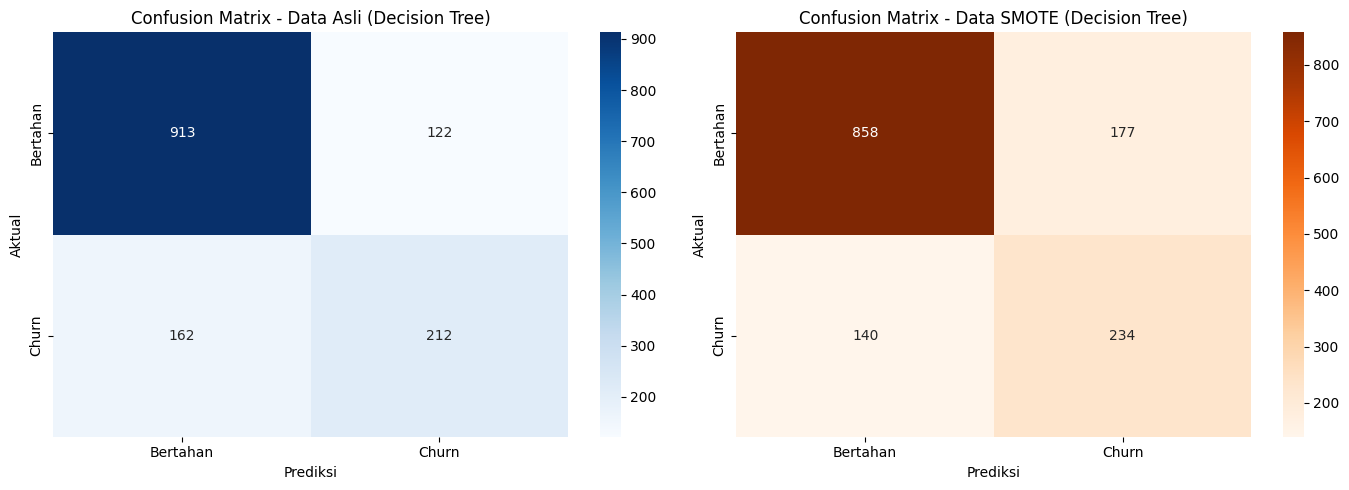

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Heatmap Data Asli
cm_asli = confusion_matrix(y_test, y_pred_asli)
sns.heatmap(cm_asli, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Bertahan', 'Churn'], yticklabels=['Bertahan', 'Churn'])
ax[0].set_title('Confusion Matrix - Data Asli (Decision Tree)')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

# Plot Heatmap Data SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Oranges', ax=ax[1],
            xticklabels=['Bertahan', 'Churn'], yticklabels=['Bertahan', 'Churn'])
ax[1].set_title('Confusion Matrix - Data SMOTE (Decision Tree)')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

# 10. Detail Perbandingan

In [31]:
print("KESIMPULAN EVALUASI (DATA ASLI VS SMOTE)")
print(f"{'Metrik':<20} {'Data Asli':>12} {'Data SMOTE':>12}")
print("-" * 46)
print(f"{'Akurasi':<20} {acc_asli*100:>11.2f}% {acc_smote*100:>11.2f}%")
print(f"{'ROC-AUC':<20} {roc_asli:>12.4f} {roc_smote:>12.4f}")
print(f"{'F1-Score':<20} {f1_asli:>12.4f} {f1_smote:>12.4f}")

if roc_asli >= roc_smote:
    print(f"\nROC-AUC DATA ASLI ({roc_asli:.4f}) lebih unggul.")
    model_final = dt_asli_final
    best_params_final = best_params_asli
else:
    print(f"\nROC-AUC DATA SMOTE ({roc_smote:.4f}) lebih unggul.")
    model_final = dt_smote_final
    best_params_final = best_params_smote

KESIMPULAN EVALUASI (DATA ASLI VS SMOTE)
Metrik                  Data Asli   Data SMOTE
----------------------------------------------
Akurasi                    79.84%       77.50%
ROC-AUC                    0.8303       0.8136
F1-Score                   0.5989       0.5962

ROC-AUC DATA ASLI (0.8303) lebih unggul.


# 11. Simpan Model

In [32]:
# Target folder
target_dir = '../models'
os.makedirs(target_dir, exist_ok=True)

# 1. Simpan model pemenang
joblib.dump(model_final, os.path.join(target_dir, 'dt_model.pkl'))

# 2. Simpan preprocessor 
joblib.dump(preprocessor, os.path.join(target_dir, 'dt_preprocessor.pkl'))

# 3. Simpan nama kolom/fitur final
joblib.dump(nama_fitur_final, os.path.join(target_dir, 'dt_selected_features.pkl'))

# 4. Simpan parameter terbaik JSON
with open(os.path.join(target_dir, 'best_params_dt.json'), 'w') as f:
    json.dump(best_params_final, f, indent=2)

# 5. Simpan metadata
metadata = {
    'accuracy': accuracy_score(y_test, model_final.predict(X_test_processed)),
    'auc': roc_auc_score(y_test, model_final.predict_proba(X_test_processed)[:, 1]),
    'macro_f1': f1_score(y_test, model_final.predict(X_test_processed), average='macro'),
    'n_features': len(nama_fitur_final)
}
joblib.dump(metadata, os.path.join(target_dir, 'dt_metadata.pkl'))

print("✅ Seluruh file model Decision Tree sukses diexport ke folder 'models/'!")

✅ Seluruh file model Decision Tree sukses diexport ke folder 'models/'!


# 12. Sanity Check

In [33]:
# Menguji 5 sampel data pertama dari pengujian menggunakan model terbaik
sampel_uji = X_test_processed[:5]
hasil_prediksi = model_final.predict(sampel_uji)
probabilitas = model_final.predict_proba(sampel_uji)[:, 1]

tabel_pengecekan = pd.DataFrame({
    'Data Aktual'       : y_test.iloc[:5].values,
    'Prediksi Model DT' : hasil_prediksi,
    'Probabilitas Churn': probabilitas.round(3)
})

print("\n=== HASIL SANITY CHECK FINAL MODEL ===")
print(tabel_pengecekan)


=== HASIL SANITY CHECK FINAL MODEL ===
   Data Aktual  Prediksi Model DT  Probabilitas Churn
0            0                  0               0.000
1            0                  1               0.721
2            0                  0               0.108
3            0                  1               0.568
4            0                  0               0.009
